### 时间序列数据预测

In [1]:
import pandas_datareader as pdr
gs10 = pdr.get_data_fred('GS10')
gs10.head()
# 展现gs10数据的5行（默认）

,GS10
DATE,
2020-06-01,0.73
2020-07-01,0.62
2020-08-01,0.65
2020-09-01,0.68
2020-10-01,0.79


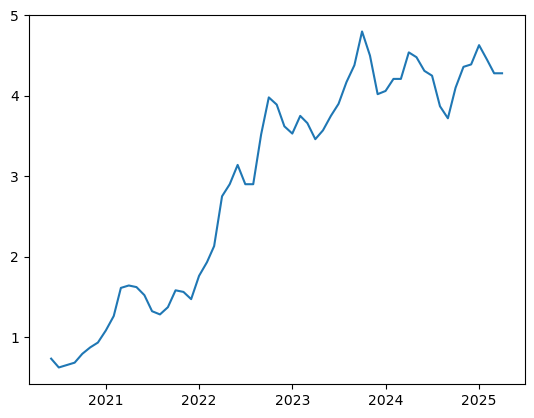

In [2]:
import matplotlib.pyplot as plt
plt.plot(gs10)
# 直接绘制gs10数据
# gs10的索引（日期）回自动作为x轴，GS10列的数值作为y轴
plt.show()

In [3]:
import torch
from torch.utils.data import DataLoader, TensorDataset

num = len(gs10)
x = torch.tensor(gs10['GS10'].to_list())
seq_len = 6
batch_size = 4

X_feature = torch.zeros((num - seq_len, seq_len))
for i in range(seq_len):
    X_feature[:,i] = x[i: num - seq_len + i]
y_label = x[seq_len:].reshape((-1,1))

train_loader = DataLoader(TensorDataset(X_feature[:num-seq_len], 
    y_label[:num-seq_len]), batch_size=batch_size, shuffle=True)
# TensorDataset(X_feature, y _label):将特征X_feature 和标签y_label封装成一个数据集对象

In [4]:
train_loader.dataset[:batch_size]

(tensor([[0.7300, 0.6200, 0.6500, 0.6800, 0.7900, 0.8700],
         [0.6200, 0.6500, 0.6800, 0.7900, 0.8700, 0.9300],
         [0.6500, 0.6800, 0.7900, 0.8700, 0.9300, 1.0800],
         [0.6800, 0.7900, 0.8700, 0.9300, 1.0800, 1.2600]]),
 tensor([[0.9300],
         [1.0800],
         [1.2600],
         [1.6100]]))

In [5]:
from torch import nn
from tqdm import *

class Model(nn.Module):
    def __init__(self, input_size, output_size, num_hiddens):
        super().__init__()
        self.linear1 = nn.Linear(input_size,num_hiddens)
        self.linear2 = nn.Linear(num_hiddens, output_size)

    def forward(self, X):
        output = torch.relu(self.linear1(X))
        output = self.linear2(output)
        return output

input_size = seq_len
output_size = 1
num_hiddens = 10
lr = 0.01

model = Model(input_size, output_size, num_hiddens)
criterion = nn.MSELoss(reduction = 'none')
trainer = torch.optim.Adam(model.parameters(), lr)

 70%|███████   | 14/20 [00:00<00:00, 62.03it/s]

Epoch 1: Validation loss = 0.6601
Epoch 2: Validation loss = 0.2056
Epoch 3: Validation loss = 0.1428
Epoch 4: Validation loss = 0.1497
Epoch 5: Validation loss = 0.1306
Epoch 6: Validation loss = 0.1239
Epoch 7: Validation loss = 0.1186
Epoch 8: Validation loss = 0.1193
Epoch 9: Validation loss = 0.1173
Epoch 10: Validation loss = 0.1143
Epoch 11: Validation loss = 0.1083
Epoch 12: Validation loss = 0.1124
Epoch 13: Validation loss = 0.1056
Epoch 14: Validation loss = 0.1043


100%|██████████| 20/20 [00:00<00:00, 65.04it/s]

Epoch 15: Validation loss = 0.1002
Epoch 16: Validation loss = 0.1052
Epoch 17: Validation loss = 0.1093
Epoch 18: Validation loss = 0.1153
Epoch 19: Validation loss = 0.1214
Epoch 20: Validation loss = 0.1070


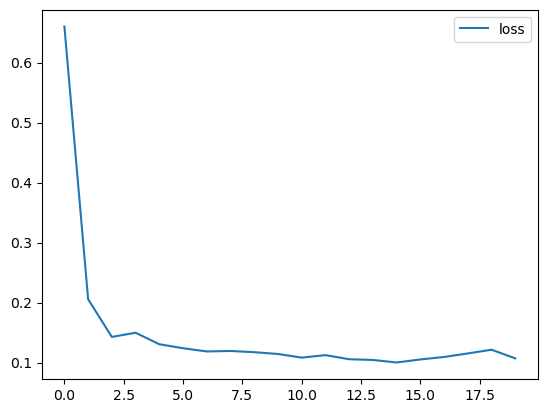

In [6]:
num_epochs = 20
loss_history = []

for epoch in tqdm(range(num_epochs)):
    # 批量训练
    for X, y in train_loader:
        trainer.zero_grad()
        y_pred = model(X)
        loss = criterion(y_pred, y)
        loss.sum().backward()
        trainer.step()
    # 输出损失
    with torch.no_grad():
        total_loss = 0
        for X, y in train_loader:
            y_pred = model(X)
            loss = criterion(y_pred, y)
            total_loss += loss.sum()/loss.numel()
        avg_loss = total_loss / len(train_loader)
        print(f'Epoch {epoch+1}: Validation loss = {avg_loss:.4f}')
        loss_history.append(avg_loss)
    
# 绘制损失和准确率的曲线图
import matplotlib.pyplot as plt
plt.plot(loss_history, label='loss')
plt.legend()
plt.show() 

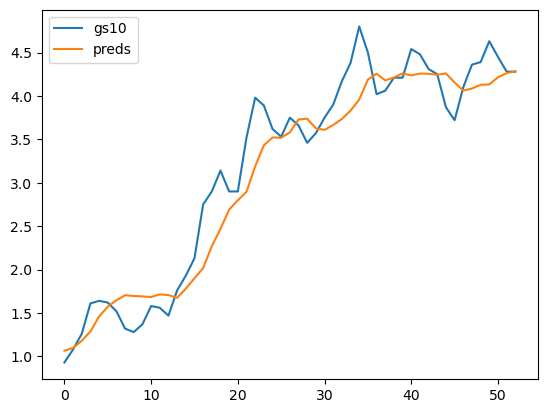

In [10]:
preds = model(X_feature)
time = torch.arange(1+ num+1, dtype = torch.float32)

plt.plot(time[:num - seq_len], gs10['GS10'].to_list()[seq_len:num],label = 'gs10')
plt.plot(time[:num - seq_len], preds.detach().numpy(), label = 'preds')
plt.legend()
plt.show()

In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset

num = len(gs10)                           # 总数据量，59
x = torch.tensor(gs10['GS10'].to_list())  # 股价列表
seq_len = 6                               # 预测序列长度
batch_size = 4                            # 设置批大小

X_feature = torch.zeros((num - seq_len, seq_len))      # 构建特征矩阵，num-seq_len行，seq_len列，初始值均为0
Y_label = torch.zeros((num - seq_len, seq_len))        # 构建标签矩阵，形状同特征矩阵
for i in range(seq_len):
    X_feature[:, i] = x[i: num - seq_len + i]    # 为特征矩阵赋值
    Y_label[:, i] = x[i+1: num - seq_len + i + 1]    # 为标签矩阵赋值

train_loader = DataLoader(TensorDataset(
    X_feature[:num-seq_len].unsqueeze(2), Y_label[:num-seq_len]),
    batch_size=batch_size, shuffle=True)  # 构建数据加载器

NameError: name 'gs10' is not defined

In [1]:
train_loader.dataset[:batch_size]

NameError: name 'train_loader' is not defined

In [2]:
from torch import nn
from tqdm import *

class RNNModel(nn.Module):
    def __init__(self, input_size, output_size, num_hiddens, n_layers):
        super(RNNModel, self).__init__()
        self.num_hiddens = num_hiddens
        self.n_layers = n_layers
        self.rnn = nn.RNN(input_size, num_hiddens, n_layers, batch_first = True)
        self.linear = nn.Linear(num_hiddens, output_size)
       
    def forward(self, X):
        batch_size = X.size(0)
        state = self.begin_state(batch_size)
        output, state = self.rnn(X, state)
        output = self.linear(torch.relu(output))
        return output, state

    def begin_state(self, batch_size=1):
        return  torch.zeros(self.n_layers, batch_size, self.num_hiddens)

In [1]:
# 定义超参数
input_size = seq_len
output_size = 1
num_hiddens = 10  
lr = 0.01

NameError: name 'seq_len' is not defined

In [1]:
model = RNNModel(input_size, output_size, num_hiddens, n_layers)
criterion = nn.MSELoss(reduction='none')
trainer = torch.optim.Adam(model.parameters(), lr)

NameError: name 'RNNModel' is not defined

In [ ]:
num_epochs = 20
rnn_loss_history = []